# Notebook 2: Análisis supervisado y no supervisado con Spark MLlib

## Proyecto: Satisfacción del cliente en servicios

Este notebook corresponde al Bloque 2 del proyecto. Se utiliza Apache Spark MLlib para aplicar técnicas de aprendizaje no supervisado y supervisado sobre el dataset sintético generado en el Bloque 1.

In [1]:
import os

os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Proyecto_Satisfaccion_Cliente_Spark_MLlib") \
    .master("local[*]") \
    .config("spark.sql.debug.maxToStringFields", "200") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

In [2]:
df = spark.read.csv(
    "../data/processed/dataset_satisfaccion_cliente.csv",
    header=True,
    inferSchema=True
)

df.printSchema()
df.show(5)

root
 |-- id_cliente: string (nullable = true)
 |-- id_servicio: string (nullable = true)
 |-- id_region: string (nullable = true)
 |-- id_sede: string (nullable = true)
 |-- id_agente: string (nullable = true)
 |-- id_campania: string (nullable = true)
 |-- id_ticket_reciente: string (nullable = true)
 |-- edad: double (nullable = true)
 |-- genero: string (nullable = true)
 |-- nivel_ingreso: string (nullable = true)
 |-- segmento_cliente: string (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- tipo_cliente: string (nullable = true)
 |-- nivel_digitalizacion: double (nullable = true)
 |-- zona_residencia: string (nullable = true)
 |-- ocupacion: string (nullable = true)
 |-- frecuencia_uso_mensual: integer (nullable = true)
 |-- sesiones_app_mensual: integer (nullable = true)
 |-- llamadas_callcenter_3m: integer (nullable = true)
 |-- reclamos_6m: integer (nullable = true)
 |-- tickets_abiertos_6m: integer (nullable = true)
 |-- tickets_resueltos_6m: integer (nu

In [3]:
print("Filas:", df.count())
print("Columnas:", len(df.columns))

Filas: 15150
Columnas: 59


In [4]:
df = df.dropDuplicates()

print("Filas después de eliminar duplicados:", df.count())

Filas después de eliminar duplicados: 15000


In [5]:
label_col = "satisfaccion_alta"

La variable objetivo del análisis supervisado es `satisfaccion_alta`, una variable binaria donde 1 representa clientes con satisfacción alta y 0 representa clientes con satisfacción baja.

In [6]:
numeric_cols = [
    "edad",
    "antiguedad_meses",
    "nivel_digitalizacion",
    "frecuencia_uso_mensual",
    "sesiones_app_mensual",
    "llamadas_callcenter_3m",
    "reclamos_6m",
    "tickets_abiertos_6m",
    "tickets_resueltos_6m",
    "cancelaciones_previas",
    "cambios_plan_12m",
    "uso_chatbot_mensual",
    "visitas_web_mensual",
    "tiempo_espera_promedio_min",
    "tiempo_resolucion_promedio_h",
    "numero_escalamientos",
    "cumplimiento_sla",
    "disponibilidad_servicio_pct",
    "interrupciones_servicio_3m",
    "calidad_atencion_score",
    "tiempo_primera_respuesta_min",
    "resolucion_primer_contacto",
    "valor_plan_mensual",
    "pagos_atrasados_6m",
    "monto_total_pagado_12m",
    "descuentos_recibidos_12m",
    "cargos_extra_6m",
    "saldo_pendiente",
    "consumo_servicio_promedio",
    "mes_registro",
    "trimestre",
    "es_fin_de_semana",
    "temporada_alta",
    "meses_desde_ultimo_reclamo",
    "tasa_resolucion_tickets",
    "reclamos_por_mes",
    "uso_digital_total",
    "intensidad_contacto",
    "ratio_pagos_atrasados",
    "indice_problemas_servicio",
    "indice_valor_cliente",
    "indice_experiencia"
]

categorical_cols = [
    "genero",
    "nivel_ingreso",
    "segmento_cliente",
    "tipo_cliente",
    "zona_residencia",
    "ocupacion",
    "prioridad_ticket",
    "dia_semana_ultima_interaccion",
    "id_region",
    "id_sede"
]

La variable `score_satisfaccion` no se utiliza como predictor, ya que fue una variable auxiliar de la simulación. Incluirla podría generar fuga de información y producir una evaluación artificialmente optimista.

In [7]:
from pyspark.ml.feature import (
    StringIndexer,
    OneHotEncoder,
    VectorAssembler,
    StandardScaler,
    Imputer
)

imputed_cols = [c + "_imp" for c in numeric_cols]

imputer = Imputer(
    inputCols=numeric_cols,
    outputCols=imputed_cols
).setStrategy("median")

indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=c + "_idx",
        handleInvalid="keep"
    )
    for c in categorical_cols
]

encoders = [
    OneHotEncoder(
        inputCol=c + "_idx",
        outputCol=c + "_ohe"
    )
    for c in categorical_cols
]

assembler = VectorAssembler(
    inputCols=imputed_cols + [c + "_ohe" for c in categorical_cols],
    outputCol="features_raw",
    handleInvalid="keep"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=False,
    withStd=True
)

preprocessing_stages = [imputer] + indexers + encoders + [assembler, scaler]

In [8]:
from pyspark.ml import Pipeline
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

silhouette_results = []

for k in range(2, 9):
    kmeans = KMeans(
        featuresCol="features",
        predictionCol="cluster",
        k=k,
        seed=33,
        maxIter=30
    )

    pipeline_kmeans = Pipeline(stages=preprocessing_stages + [kmeans])
    model_kmeans = pipeline_kmeans.fit(df)
    predictions_kmeans = model_kmeans.transform(df)

    evaluator_cluster = ClusteringEvaluator(
        featuresCol="features",
        predictionCol="cluster",
        metricName="silhouette"
    )

    silhouette = evaluator_cluster.evaluate(predictions_kmeans)
    silhouette_results.append((k, silhouette))

    print(f"K={k} | Silhouette={silhouette:.4f}")

K=2 | Silhouette=0.0687
K=3 | Silhouette=0.0504
K=4 | Silhouette=0.0474
K=5 | Silhouette=0.0552
K=6 | Silhouette=0.0476
K=7 | Silhouette=0.0513
K=8 | Silhouette=0.0436


In [9]:
import pandas as pd

silhouette_df = pd.DataFrame(
    silhouette_results,
    columns=["K", "Silhouette"]
)

silhouette_df

,K,Silhouette
0,2,0.068651
1,3,0.050431
2,4,0.047377
3,5,0.055222
4,6,0.047619
5,7,0.051313
6,8,0.043575


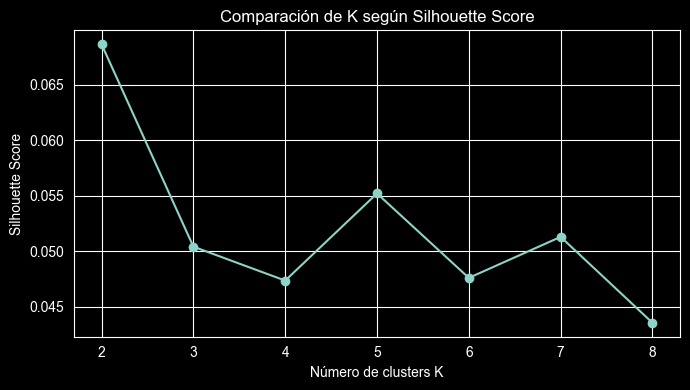

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(silhouette_df["K"], silhouette_df["Silhouette"], marker="o")
plt.title("Comparación de K según Silhouette Score")
plt.xlabel("Número de clusters K")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
best_k = silhouette_df.sort_values("Silhouette", ascending=False).iloc[0]["K"]
best_k = int(best_k)

print("Mejor K:", best_k)

Mejor K: 2


In [12]:
kmeans_final = KMeans(
    featuresCol="features",
    predictionCol="cluster",
    k=best_k,
    seed=33,
    maxIter=30
)

pipeline_kmeans_final = Pipeline(stages=preprocessing_stages + [kmeans_final])
model_kmeans_final = pipeline_kmeans_final.fit(df)
clusters = model_kmeans_final.transform(df)

In [13]:
clusters.groupBy("cluster").count().orderBy("cluster").show()

+-------+-----+
|cluster|count|
+-------+-----+
|      0| 9052|
|      1| 5948|
+-------+-----+



In [14]:
cluster_profile = clusters.groupBy("cluster").avg(
    "reclamos_6m",
    "tiempo_espera_promedio_min",
    "tiempo_resolucion_promedio_h",
    "calidad_atencion_score",
    "disponibilidad_servicio_pct",
    "pagos_atrasados_6m",
    "indice_problemas_servicio",
    "indice_experiencia",
    "satisfaccion_alta"
).orderBy("cluster")

cluster_profile.show(truncate=False)

+-------+------------------+-------------------------------+---------------------------------+---------------------------+--------------------------------+-----------------------+------------------------------+-----------------------+----------------------+
|cluster|avg(reclamos_6m)  |avg(tiempo_espera_promedio_min)|avg(tiempo_resolucion_promedio_h)|avg(calidad_atencion_score)|avg(disponibilidad_servicio_pct)|avg(pagos_atrasados_6m)|avg(indice_problemas_servicio)|avg(indice_experiencia)|avg(satisfaccion_alta)|
+-------+------------------+-------------------------------+---------------------------------+---------------------------+--------------------------------+-----------------------+------------------------------+-----------------------+----------------------+
|0      |0.5469509500662837|8.703483345124356              |12.020858928322133               |7.138081717215323          |95.91932891523578               |0.7863455589924878     |2.046398585947857             |15.9157046353116

El clustering permitió identificar segmentos de clientes según sus patrones de experiencia. Los clusters se interpretan a partir de variables como reclamos, tiempo de espera, calidad de atención, pagos atrasados, índice de problemas e índice de experiencia.

El mejor valor de K fue 2. El Cluster 0 agrupó clientes con menor promedio de reclamos e índice de problemas, mientras que el Cluster 1 concentró clientes con mayor fricción operativa. Además, el Cluster 0 presentó una mayor proporción promedio de satisfacción alta, lo que indica que la segmentación es coherente con la lógica del problema.

In [15]:
train, test = df.randomSplit([0.8, 0.2], seed=33)

print("Train:", train.count())
print("Test:", test.count())

Train: 11956
Test: 3044


In [16]:
from pyspark.ml.classification import (
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier,
    GBTClassifier
)

modelos = {
    "Logistic Regression": LogisticRegression(
        featuresCol="features",
        labelCol=label_col,
        maxIter=50
    ),
    "Decision Tree": DecisionTreeClassifier(
        featuresCol="features",
        labelCol=label_col,
        seed=33,
        maxDepth=6
    ),
    "Random Forest": RandomForestClassifier(
        featuresCol="features",
        labelCol=label_col,
        seed=33,
        numTrees=100,
        maxDepth=8
    ),
    "GBT": GBTClassifier(
        featuresCol="features",
        labelCol=label_col,
        seed=33,
        maxIter=50,
        maxDepth=5
    )
}

In [17]:
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator
)

def evaluar_modelo(predictions, nombre_modelo):
    evaluator_acc = MulticlassClassificationEvaluator(
        labelCol=label_col,
        predictionCol="prediction",
        metricName="accuracy"
    )

    evaluator_precision = MulticlassClassificationEvaluator(
        labelCol=label_col,
        predictionCol="prediction",
        metricName="weightedPrecision"
    )

    evaluator_recall = MulticlassClassificationEvaluator(
        labelCol=label_col,
        predictionCol="prediction",
        metricName="weightedRecall"
    )

    evaluator_f1 = MulticlassClassificationEvaluator(
        labelCol=label_col,
        predictionCol="prediction",
        metricName="f1"
    )

    evaluator_auc = BinaryClassificationEvaluator(
        labelCol=label_col,
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    )

    accuracy = evaluator_acc.evaluate(predictions)
    precision = evaluator_precision.evaluate(predictions)
    recall = evaluator_recall.evaluate(predictions)
    f1 = evaluator_f1.evaluate(predictions)
    auc = evaluator_auc.evaluate(predictions)

    return {
        "Modelo": nombre_modelo,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    }

In [18]:
resultados = []
matrices_confusion = {}

for nombre, modelo in modelos.items():
    pipeline = Pipeline(stages=preprocessing_stages + [modelo])
    fitted_model = pipeline.fit(train)
    predictions = fitted_model.transform(test)

    metricas = evaluar_modelo(predictions, nombre)
    resultados.append(metricas)

    print(f"\nModelo: {nombre}")
    print(metricas)

    matriz = predictions.groupBy(label_col, "prediction").count().orderBy(label_col, "prediction")
    matriz.show()

    matrices_confusion[nombre] = matriz


Modelo: Logistic Regression
{'Modelo': 'Logistic Regression', 'Accuracy': 0.6386333771353482, 'Precision': 0.6399119554013201, 'Recall': 0.6386333771353483, 'F1': 0.6384061779016937, 'AUC': 0.6879651094497112}
+-----------------+----------+-----+
|satisfaccion_alta|prediction|count|
+-----------------+----------+-----+
|                0|       0.0|  946|
|                0|       1.0|  606|
|                1|       0.0|  494|
|                1|       1.0|  998|
+-----------------+----------+-----+


Modelo: Decision Tree
{'Modelo': 'Decision Tree', 'Accuracy': 0.5978975032851511, 'Precision': 0.6019804152134258, 'Recall': 0.5978975032851511, 'F1': 0.5957894552386032, 'AUC': 0.6238426245819628}
+-----------------+----------+-----+
|satisfaccion_alta|prediction|count|
+-----------------+----------+-----+
|                0|       0.0|  814|
|                0|       1.0|  738|
|                1|       0.0|  486|
|                1|       1.0| 1006|
+-----------------+----------+----

In [19]:
resultados_df = pd.DataFrame(resultados)
resultados_df

,Modelo,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.638633,0.639912,0.638633,0.638406,0.687965
1,Decision Tree,0.597898,0.601980,0.597898,0.595789,0.623843
2,Random Forest,0.621222,0.621911,0.621222,0.621169,0.672183
3,GBT,0.611038,0.612144,0.611038,0.610820,0.659927


In [20]:
resultados_df.to_csv("../reports/tablas/comparacion_modelos.csv", index=False)

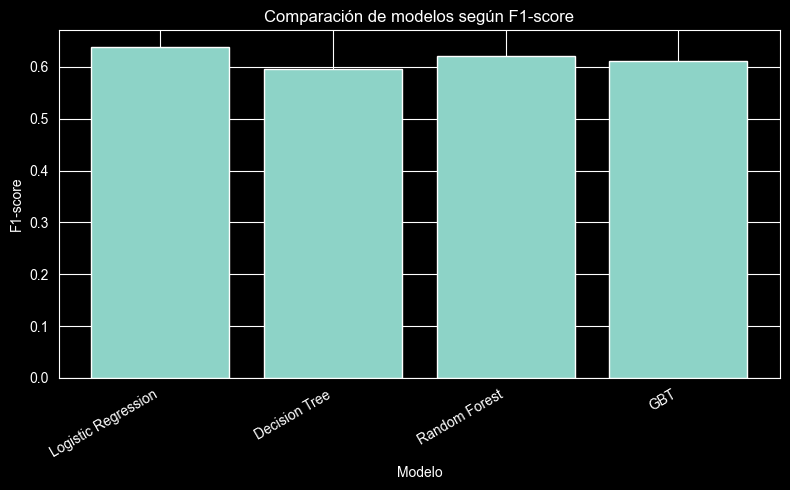

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(resultados_df["Modelo"], resultados_df["F1"])
plt.title("Comparación de modelos según F1-score")
plt.xlabel("Modelo")
plt.ylabel("F1-score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [22]:
mejor_f1 = resultados_df.sort_values("F1", ascending=False).iloc[0]
mejor_auc = resultados_df.sort_values("AUC", ascending=False).iloc[0]

print("Mejor modelo según F1:")
print(mejor_f1)

print("\nMejor modelo según AUC:")
print(mejor_auc)

Mejor modelo según F1:
Modelo       Logistic Regression
Accuracy                0.638633
Precision               0.639912
Recall                  0.638633
F1                      0.638406
AUC                     0.687965
Name: 0, dtype: object

Mejor modelo según AUC:
Modelo       Logistic Regression
Accuracy                0.638633
Precision               0.639912
Recall                  0.638633
F1                      0.638406
AUC                     0.687965
Name: 0, dtype: object


El mejor modelo fue Logistic Regression, tanto por F1-score como por AUC. Esto indica que la estructura de la variable objetivo puede ser capturada adecuadamente mediante una frontera de decisión lineal.

In [23]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

In [24]:
rf_tuning = RandomForestClassifier(
    featuresCol="features",
    labelCol=label_col,
    seed=33
)

pipeline_rf_tuning = Pipeline(
    stages=preprocessing_stages + [rf_tuning]
)

paramGrid_rf = ParamGridBuilder() \
    .addGrid(rf_tuning.numTrees, [50, 100]) \
    .addGrid(rf_tuning.maxDepth, [5, 8]) \
    .addGrid(rf_tuning.featureSubsetStrategy, ["sqrt", "log2"]) \
    .build()

evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol=label_col,
    predictionCol="prediction",
    metricName="f1"
)

cv_rf = CrossValidator(
    estimator=pipeline_rf_tuning,
    estimatorParamMaps=paramGrid_rf,
    evaluator=evaluator_f1,
    numFolds=2,
    seed=33,
    parallelism=2
)

cv_model_rf = cv_rf.fit(train)
pred_rf_tuned = cv_model_rf.transform(test)

metricas_rf_tuned = evaluar_modelo(pred_rf_tuned, "Random Forest Tuned")
metricas_rf_tuned

{'Modelo': 'Random Forest Tuned',
 'Accuracy': 0.6162943495400789,
 'Precision': 0.6164574881578573,
 'Recall': 0.6162943495400788,
 'F1': 0.616330960856808,
 'AUC': 0.668430944418341}

In [25]:
gbt_tuning = GBTClassifier(
    featuresCol="features",
    labelCol=label_col,
    seed=33
)

pipeline_gbt_tuning = Pipeline(
    stages=preprocessing_stages + [gbt_tuning]
)

paramGrid_gbt = ParamGridBuilder() \
    .addGrid(gbt_tuning.maxIter, [30, 50]) \
    .addGrid(gbt_tuning.maxDepth, [3, 5]) \
    .addGrid(gbt_tuning.stepSize, [0.05, 0.1]) \
    .build()

cv_gbt = CrossValidator(
    estimator=pipeline_gbt_tuning,
    estimatorParamMaps=paramGrid_gbt,
    evaluator=evaluator_f1,
    numFolds=2,
    seed=33,
    parallelism=2
)

cv_model_gbt = cv_gbt.fit(train)
pred_gbt_tuned = cv_model_gbt.transform(test)

metricas_gbt_tuned = evaluar_modelo(pred_gbt_tuned, "GBT Tuned")
metricas_gbt_tuned

{'Modelo': 'GBT Tuned',
 'Accuracy': 0.6228646517739816,
 'Precision': 0.6233947509574493,
 'Recall': 0.6228646517739816,
 'F1': 0.622854232231276,
 'AUC': 0.6715839287194941}

In [26]:
resultados_finales = resultados + [metricas_rf_tuned, metricas_gbt_tuned]
resultados_finales_df = pd.DataFrame(resultados_finales)

resultados_finales_df

,Modelo,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.638633,0.639912,0.638633,0.638406,0.687965
1,Decision Tree,0.597898,0.601980,0.597898,0.595789,0.623843
2,Random Forest,0.621222,0.621911,0.621222,0.621169,0.672183
3,GBT,0.611038,0.612144,0.611038,0.610820,0.659927
4,Random Forest Tuned,0.616294,0.616457,0.616294,0.616331,0.668431
5,GBT Tuned,0.622865,0.623395,0.622865,0.622854,0.671584


In [27]:
resultados_finales_df.to_csv("../reports/tablas/comparacion_modelos_final.csv", index=False)

## Conclusiones del Bloque 2

El análisis no supervisado permitió segmentar clientes en grupos diferenciados según su experiencia de servicio. El mejor número de clusters se seleccionó mediante Silhouette Score y posteriormente se interpretaron los segmentos con base en reclamos, tiempos de atención, calidad percibida e índice de problemas.

En el análisis supervisado se entrenaron y compararon cuatro modelos de clasificación: Logistic Regression, Decision Tree, Random Forest y Gradient-Boosted Trees. Los modelos fueron evaluados mediante Accuracy, Precision, Recall, F1-score, AUC y matriz de confusión.

El modelo recomendado fue seleccionado con base en F1-score y AUC, ya que estas métricas permiten evaluar tanto el balance entre precision y recall como la capacidad general de discriminación del modelo. En el contexto de satisfacción del cliente, se considera especialmente crítico evitar clasificar como satisfechos a clientes que realmente tienen baja satisfacción, ya que esto podría impedir acciones correctivas o estrategias de retención.